In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Semiconds subset from Comtrade
Streams in the whole dataset then it gets only the semiconductors based on their headings. Then it saves it all in a parquet file

In [3]:
# ---- config --------------------- -------------------------------------
SRC = "comtradeExports_updatedH5[240924]-wb.csv.gz"   # input (.csv or .csv.gz)
OUT = "chip_trade_2017_2023.parquet"                  # output

# HS-4 headings that count as "chips/electronics".
# Strict semiconductors only -> ["8541", "8542"]
CHIP_HEADINGS = ["8517", "8541", "8542"]

CHUNK = 200_000

# Columns we keep (drop the rest: CIFValue, qty/altQty, estimation flags...)
KEEP = [
    "refYear", "reporterCode", "partnerCode", "cmdCode", "flowCode",
    "primaryValue", "FOBValue", "netWgt", "isAggregate",
    "pop_o", "gdp_o", "gdpcap_o", "pop_d", "gdp_d", "gdpcap_d", "dist",
]
NUMERIC = ["primaryValue", "FOBValue", "netWgt",
           "pop_o", "gdp_o", "gdpcap_o", "pop_d", "gdp_d", "gdpcap_d", "dist"]
GRAVITY = ["pop_o", "gdp_o", "gdpcap_o", "pop_d", "gdp_d", "gdpcap_d", "dist"]

# ---- only read columns that actually exist (robustness) --------------
available = pd.read_csv(SRC, nrows=0).columns.tolist()
keep = [c for c in KEEP if c in available]
missing_cols = [c for c in KEEP if c not in available]
if missing_cols:
    print("WARNING — these columns weren't found and will be skipped:", missing_cols)
numeric = [c for c in NUMERIC if c in keep]
gravity = [c for c in GRAVITY if c in keep]

# ---- streaming filter ------------------------------------------------
prefixes = tuple(CHIP_HEADINGS)
parts, total = [], 0
print(f"Filtering {SRC} to headings {CHIP_HEADINGS} ...")
reader = pd.read_csv(SRC, usecols=keep, chunksize=CHUNK, dtype=str, low_memory=False)
for i, chunk in enumerate(reader, 1):
    total += len(chunk)
    code = chunk["cmdCode"].astype(str).str.zfill(6)
    mask = code.str.startswith(prefixes[0])
    for p in prefixes[1:]:
        mask = mask | code.str.startswith(p)
    hit = chunk[mask]
    if len(hit):
        parts.append(hit)
    if i % 10 == 0:
        kept = sum(len(p) for p in parts)
        print(f"  scanned {total:,} rows  ->  kept {kept:,}")

if not parts:
    raise ValueError("No rows matched — check CHIP_HEADINGS / cmdCode format.")

df = pd.concat(parts, ignore_index=True)
print(f"\nScanned {total:,} rows. Chip subset: {len(df):,} rows.")

# ---- typing & helper column -----------------------------------------
for c in numeric:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["heading"] = df["cmdCode"].astype(str).str.zfill(6).str[:4]

# ---- save (parquet, with csv fallback) ------------------------------
try:
    df.to_parquet(OUT, index=False)
    print(f"Saved -> {OUT}")
except Exception as e:
    OUT = OUT.replace(".parquet", ".csv.gz")
    df.to_csv(OUT, index=False, compression="gzip")
    print(f"(parquet unavailable: {e})\nSaved -> {OUT}")

# =====================================================================
# Summary — this is what tells us how to use it
# =====================================================================
print("\n" + "=" * 56)
print("CHIP SUBSET SUMMARY")
print("=" * 56)
print(f"\nRows: {len(df):,}")
print(f"Years: {sorted(df['refYear'].dropna().unique().tolist())}")
print(f"Exporters: {df['reporterCode'].nunique()}   "
      f"Importers: {df['partnerCode'].nunique()}")

print("\nRows per heading:")
print(df["heading"].value_counts().to_string())

print("\nisAggregate split (we still need to decide which to keep):")
print(df["isAggregate"].value_counts(dropna=False).to_string())

print("\nMissing-gravity rate in the subset (sets the drop/impute rule):")
for c in gravity:
    print(f"  {c:9} {df[c].isna().mean()*100:5.1f}% missing")
full = df[gravity].notna().all(axis=1).sum()
print(f"  rows with ALL gravity present: {full:,} ({100*full/len(df):.1f}%)")

print("\nprimaryValue (USD) distribution:")
print(df["primaryValue"].describe().to_string())

Filtering comtradeExports_updatedH5[240924]-wb.csv.gz to headings ['8517', '8541', '8542'] ...
  scanned 2,000,000 rows  ->  kept 16,852
  scanned 4,000,000 rows  ->  kept 35,852
  scanned 6,000,000 rows  ->  kept 53,707
  scanned 8,000,000 rows  ->  kept 71,491
  scanned 10,000,000 rows  ->  kept 88,305
  scanned 12,000,000 rows  ->  kept 105,428
  scanned 14,000,000 rows  ->  kept 123,043
  scanned 16,000,000 rows  ->  kept 143,132
  scanned 18,000,000 rows  ->  kept 159,585
  scanned 20,000,000 rows  ->  kept 178,382
  scanned 22,000,000 rows  ->  kept 197,065
  scanned 24,000,000 rows  ->  kept 215,168
  scanned 26,000,000 rows  ->  kept 233,220
  scanned 28,000,000 rows  ->  kept 249,447
  scanned 30,000,000 rows  ->  kept 269,619
  scanned 32,000,000 rows  ->  kept 286,291
  scanned 34,000,000 rows  ->  kept 305,445
  scanned 36,000,000 rows  ->  kept 324,718
  scanned 38,000,000 rows  ->  kept 341,831
  scanned 40,000,000 rows  ->  kept 361,575
  scanned 42,000,000 rows  ->  kep

# Generic Comtrade Product extractor
It expects the HS prefixes and returns the products needed

In [2]:
SRC_DEFAULT = "comtradeExports_updatedH5[240924]-wb.csv.gz"

_KEEP = [
    "refYear", "reporterCode", "partnerCode", "cmdCode", "flowCode",
    "primaryValue", "FOBValue", "netWgt", "isAggregate",
    "pop_o", "gdp_o", "gdpcap_o", "pop_d", "gdp_d", "gdpcap_d", "dist",
]
_NUMERIC = ["primaryValue", "FOBValue", "netWgt",
            "pop_o", "gdp_o", "gdpcap_o", "pop_d", "gdp_d", "gdpcap_d", "dist"]
_GRAVITY = ["pop_o", "gdp_o", "gdpcap_o", "pop_d", "gdp_d", "gdpcap_d", "dist"]


def extract_products(products, src=SRC_DEFAULT, out=None,
                     chunk=200_000, extra_cols=None, verbose=True):
    """
    Extract Comtrade rows whose HS code starts with any of `products`.

    products  : HS prefix or list of prefixes (str or int).
                "85"     -> whole chapter 85 (electrical machinery)
                "8542"   -> heading (integrated circuits)
                "854231" -> one 6-digit product
                ["8541", "8542"]  ->  several at once
    src       : path to the .csv or .csv.gz
    out       : if given, save result there (.parquet or .csv.gz)
    extra_cols: extra source columns to keep beyond the defaults
    returns   : pandas DataFrame of the matching rows
    """
    if products is None:                    # None = ALL products
        products = [""]                     # empty prefix matches every code
    if isinstance(products, (str, int)):
        products = [products]
    prefixes = tuple(str(p) for p in products)

    available = pd.read_csv(src, nrows=0).columns.tolist()
    keep = [c for c in _KEEP if c in available]
    if extra_cols:
        keep += [c for c in extra_cols if c in available and c not in keep]
    numeric = [c for c in _NUMERIC if c in keep]
    gravity = [c for c in _GRAVITY if c in keep]

    if verbose:
        print(f"Extracting products starting with {list(prefixes)} from {src}")

    parts, total = [], 0
    reader = pd.read_csv(src, usecols=keep, chunksize=chunk,
                         dtype=str, low_memory=False)
    for i, ch in enumerate(reader, 1):
        total += len(ch)
        code = ch["cmdCode"].astype(str).str.zfill(6)
        mask = code.str.startswith(prefixes[0])
        for p in prefixes[1:]:
            mask = mask | code.str.startswith(p)
        hit = ch[mask]
        if len(hit):
            parts.append(hit)
        if verbose and i % 10 == 0:
            print(f"  scanned {total:,}  ->  kept {sum(len(p) for p in parts):,}")

    if not parts:
        print("No rows matched those products.")
        return pd.DataFrame(columns=keep)

    df = pd.concat(parts, ignore_index=True)
    for c in numeric:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    z = df["cmdCode"].astype(str).str.zfill(6)
    df["chapter"], df["heading"] = z.str[:2], z.str[:4]

    if out:
        try:
            if out.endswith(".parquet"):
                df.to_parquet(out, index=False)
            else:
                df.to_csv(out, index=False,
                          compression="gzip" if out.endswith(".gz") else None)
            if verbose:
                print(f"Saved -> {out}")
        except Exception as e:
            alt = out.rsplit(".", 1)[0] + ".csv.gz"
            df.to_csv(alt, index=False, compression="gzip")
            if verbose:
                print(f"(parquet failed: {e}) Saved -> {alt}")

    if verbose:
        print("\n" + "=" * 52)
        print(f"MATCHED {len(df):,} rows  (scanned {total:,})")
        print("=" * 52)
        print(f"Years: {sorted(df['refYear'].dropna().unique().tolist())}")
        print(f"Exporters: {df['reporterCode'].nunique()}   "
              f"Importers: {df['partnerCode'].nunique()}")
        print("\nRows per heading (top 15):")
        print(df['heading'].value_counts().head(15).to_string())
        if "isAggregate" in df:
            print("\nisAggregate split:")
            print(df['isAggregate'].value_counts(dropna=False).to_string())
        if gravity:
            full = df[gravity].notna().all(axis=1).sum()
            print(f"\nRows with all gravity present: {full:,} ({100*full/len(df):.1f}%)")
        if "primaryValue" in df:
            print("\nprimaryValue (USD):")
            print(df['primaryValue'].describe().to_string())

    return df



In [3]:
# new product-category slices for the per-category training hypothesis
vehicles = extract_products(["87"], out="vehicles.parquet")      # HS 87 — vehicles
medical  = extract_products(["30"], out="medical.parquet")       # HS 30 — pharma / medical products
oil_fuel = extract_products(["27"], out="oil_fuel.parquet")      # HS 27 — mineral fuels / oils

# two more worth having, given your GDELT/geopolitics angle:
#cereals  = extract_products(["10"], out="cereals.parquet")       # HS 10 — cereals (wheat/corn — weather + war-driven, e.g. Ukraine grain corridor; very different economics from chips)
#metals   = extract_products(["71"], out="precious_metals.parquet")  # HS 71 — precious stones/metals (gold — classic safe-haven, reacts to geopolitical risk in the opposite direction from trade disruption)

Extracting products starting with ['87'] from comtradeExports_updatedH5[240924]-wb.csv.gz
  scanned 2,000,000  ->  kept 49,894
  scanned 4,000,000  ->  kept 100,171
  scanned 6,000,000  ->  kept 147,254
  scanned 8,000,000  ->  kept 198,443
  scanned 10,000,000  ->  kept 250,315
  scanned 12,000,000  ->  kept 300,120
  scanned 14,000,000  ->  kept 349,504
  scanned 16,000,000  ->  kept 398,632
  scanned 18,000,000  ->  kept 447,052
  scanned 20,000,000  ->  kept 493,823
  scanned 22,000,000  ->  kept 545,085
  scanned 24,000,000  ->  kept 596,559
  scanned 26,000,000  ->  kept 645,961
  scanned 28,000,000  ->  kept 697,621
  scanned 30,000,000  ->  kept 747,693
  scanned 32,000,000  ->  kept 795,998
  scanned 34,000,000  ->  kept 846,856
  scanned 36,000,000  ->  kept 895,865
  scanned 38,000,000  ->  kept 946,059
  scanned 40,000,000  ->  kept 993,518
  scanned 42,000,000  ->  kept 1,043,407
  scanned 44,000,000  ->  kept 1,095,407
  scanned 46,000,000  ->  kept 1,143,005
  scanned 48

In [ ]:
# use-case slice (evaluation) — keep this
chips = extract_products(["8541","8542"], out="chips.parquet")

# broad fallback for fast iteration
elec  = extract_products(["8517","8541","8542"], out="electronics.parquet")

# ALL products — the real training file (this is the big/slow one)
allp  = extract_products(None, out="all_products.parquet")

Extracting products starting with ['8541', '8542'] from comtradeExports_updatedH5[240924]-wb.csv.gz
  scanned 2,000,000  ->  kept 9,034
  scanned 4,000,000  ->  kept 19,017
  scanned 6,000,000  ->  kept 28,684
  scanned 8,000,000  ->  kept 38,156
  scanned 10,000,000  ->  kept 46,742
  scanned 12,000,000  ->  kept 55,869
  scanned 14,000,000  ->  kept 64,955
  scanned 16,000,000  ->  kept 75,577
  scanned 18,000,000  ->  kept 84,255
  scanned 20,000,000  ->  kept 93,933
  scanned 22,000,000  ->  kept 103,951
  scanned 24,000,000  ->  kept 113,562
  scanned 26,000,000  ->  kept 123,099
  scanned 28,000,000  ->  kept 132,049
  scanned 30,000,000  ->  kept 142,103
  scanned 32,000,000  ->  kept 151,211
  scanned 34,000,000  ->  kept 161,275
  scanned 36,000,000  ->  kept 171,650
  scanned 38,000,000  ->  kept 181,076
  scanned 40,000,000  ->  kept 191,506
  scanned 42,000,000  ->  kept 200,209
  scanned 44,000,000  ->  kept 209,728
  scanned 46,000,000  ->  kept 219,313
  scanned 48,000,0

In [3]:
import pyarrow as pa, pyarrow.parquet as pq

def extract_all_streaming(src=SRC_DEFAULT, out="all_products.parquet", chunk=200_000):
    keep = [c for c in _KEEP if c in pd.read_csv(src, nrows=0).columns]
    writer, total = None, 0
    for i, ch in enumerate(pd.read_csv(src, usecols=keep, chunksize=chunk,
                                       dtype=str, low_memory=False), 1):
        total += len(ch)
        for c in _NUMERIC:
            if c in ch: ch[c] = pd.to_numeric(ch[c], errors="coerce")
        z = ch["cmdCode"].astype(str).str.zfill(6)
        ch["chapter"], ch["heading"] = z.str[:2], z.str[:4]
        table = pa.Table.from_pandas(ch, preserve_index=False)
        if writer is None:
            writer = pq.ParquetWriter(out, table.schema)
        writer.write_table(table)
        if i % 20 == 0:
            print(f"  written {total:,} rows")
    if writer:
        writer.close()
    print(f"DONE -> {out}  ({total:,} rows)")

extract_all_streaming()

  written 4,000,000 rows
  written 8,000,000 rows
  written 12,000,000 rows
  written 16,000,000 rows
  written 20,000,000 rows
  written 24,000,000 rows
  written 28,000,000 rows
  written 32,000,000 rows
  written 36,000,000 rows
  written 40,000,000 rows
  written 44,000,000 rows
  written 48,000,000 rows
  written 52,000,000 rows
DONE -> all_products.parquet  (55,401,278 rows)


## Quick EDA for the results

In [9]:
# compact M49 code -> country name, for the countries that show up in trade
M49 = {
    "0":"World","156":"China","842":"USA","410":"South Korea","408":"North Korea",
    "392":"Japan","158":"Taiwan","490":"Other Asia,nes (≈Taiwan)","344":"Hong Kong",
    "446":"Macao","702":"Singapore","458":"Malaysia","764":"Thailand","704":"Vietnam",
    "608":"Philippines","360":"Indonesia","356":"India","276":"Germany","528":"Netherlands",
    "250":"France","826":"UK","380":"Italy","724":"Spain","56":"Belgium","372":"Ireland",
    "40":"Austria","756":"Switzerland","752":"Sweden","246":"Finland","124":"Canada",
    "484":"Mexico","76":"Brazil","36":"Australia","554":"New Zealand","643":"Russia",
    "792":"Turkey","376":"Israel","784":"UAE","682":"Saudi Arabia","616":"Poland",
    "203":"Czechia","348":"Hungary","642":"Romania","620":"Portugal","300":"Greece",
    "208":"Denmark","578":"Norway","710":"South Africa","818":"Egypt",
}
_name = lambda c: M49.get(str(c), f"[{c}]")
_bn   = lambda x: f"${x/1e9:,.1f}B"

def eda(df, name="dataset"):
    df = df.copy()
    df["refYear"]      = pd.to_numeric(df["refYear"], errors="coerce").astype("Int64")
    df["primaryValue"] = pd.to_numeric(df["primaryValue"], errors="coerce")
    df["dist"]         = pd.to_numeric(df.get("dist"), errors="coerce")
    pos = df[df["primaryValue"] > 0]

    # ---- text summary ----
    print("="*60)
    print(f"EDA — {name}")
    print("="*60)
    print(f"Rows:        {len(df):,}")
    print(f"Years:       {df['refYear'].min()} – {df['refYear'].max()}")
    print(f"Exporters:   {df['reporterCode'].nunique()}    Importers: {df['partnerCode'].nunique()}")
    print(f"Total value: {_bn(df['primaryValue'].sum())}")
    print("\nTop 5 exporters by value:")
    for c, v in df.groupby('reporterCode')['primaryValue'].sum().nlargest(5).items():
        print(f"  {_name(c):26} {_bn(v)}")

    # ---- plots ----
    try: plt.style.use("seaborn-v0_8-whitegrid")
    except Exception: pass
    fig, ax = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(f"Comtrade EDA — {name}", fontsize=15, fontweight="bold")
    C, C2 = "#2b6cb0", "#c05621"

    by_year = df.groupby("refYear")["primaryValue"].sum() / 1e9
    ax[0,0].bar(by_year.index.astype(str), by_year.values, color=C)
    ax[0,0].set_title("Total export value by year"); ax[0,0].set_ylabel("USD (billions)")

    tx = df.groupby("reporterCode")["primaryValue"].sum().nlargest(10).iloc[::-1] / 1e9
    ax[0,1].barh([_name(c) for c in tx.index], tx.values, color=C)
    ax[0,1].set_title("Top 10 exporters"); ax[0,1].set_xlabel("USD (billions)")

    ti = df.groupby("partnerCode")["primaryValue"].sum().nlargest(10).iloc[::-1] / 1e9
    ax[0,2].barh([_name(c) for c in ti.index], ti.values, color=C2)
    ax[0,2].set_title("Top 10 importers (destinations)"); ax[0,2].set_xlabel("USD (billions)")

    ax[1,0].hist(np.log10(pos["primaryValue"]), bins=60, color=C)
    ax[1,0].set_title("Distribution of log10(value)"); ax[1,0].set_xlabel("log10 USD")

    rh = df["heading"].value_counts().sort_index()
    ax[1,1].bar(rh.index, rh.values, color=C)
    ax[1,1].set_title("Rows per HS heading"); ax[1,1].set_ylabel("rows")

    g = pos.dropna(subset=["dist"])
    s = g.sample(min(20000, len(g)), random_state=0)
    ax[1,2].scatter(np.log10(s["dist"]), np.log10(s["primaryValue"]), s=5, alpha=0.2, color=C)
    ax[1,2].set_title("Gravity check: value vs distance")
    ax[1,2].set_xlabel("log10 distance (km)"); ax[1,2].set_ylabel("log10 value")

    plt.tight_layout(rect=[0,0,1,0.96]); plt.show()


EDA — Chips (8541 + 8542)
Rows:        264,816
Years:       2017 – 2023
Exporters:   156    Importers: 244
Total value: $7,576.2B

Top 5 exporters by value:
  Hong Kong                  $1,258.2B
  China                      $1,117.5B
  [975]                      $1,004.9B
  Other Asia,nes (≈Taiwan)   $786.3B
  Singapore                  $645.4B


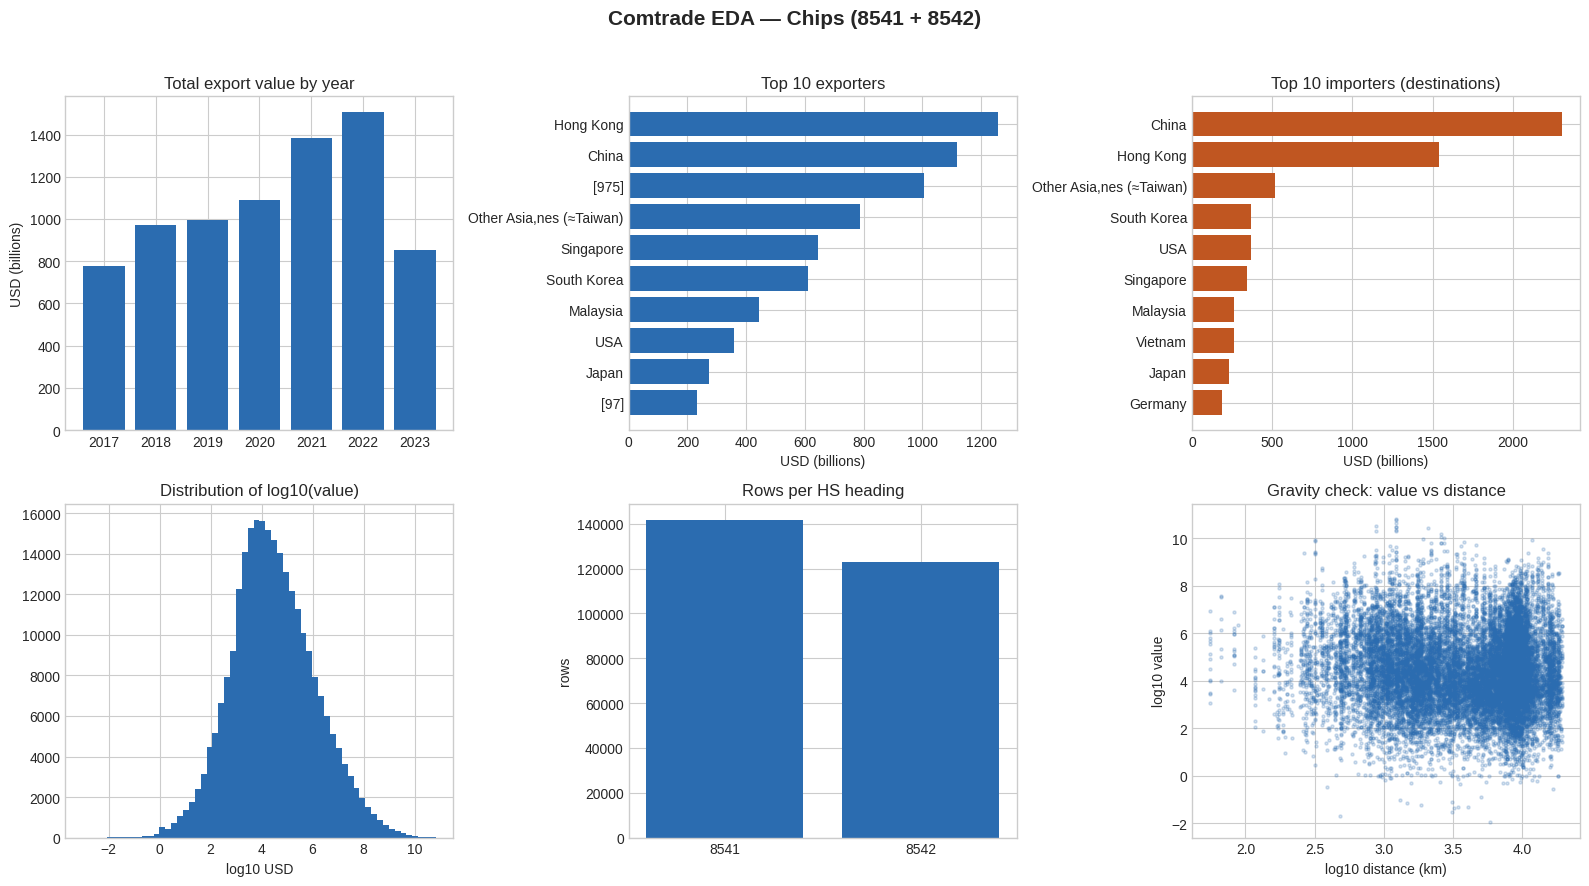

EDA — Electronics (8517 + 8541 + 8542)
Rows:        499,690
Years:       2017 – 2023
Exporters:   163    Importers: 244
Total value: $12,206.6B

Top 5 exporters by value:
  China                      $2,814.4B
  Hong Kong                  $1,762.6B
  [975]                      $1,464.1B
  Other Asia,nes (≈Taiwan)   $838.5B
  South Korea                $727.3B


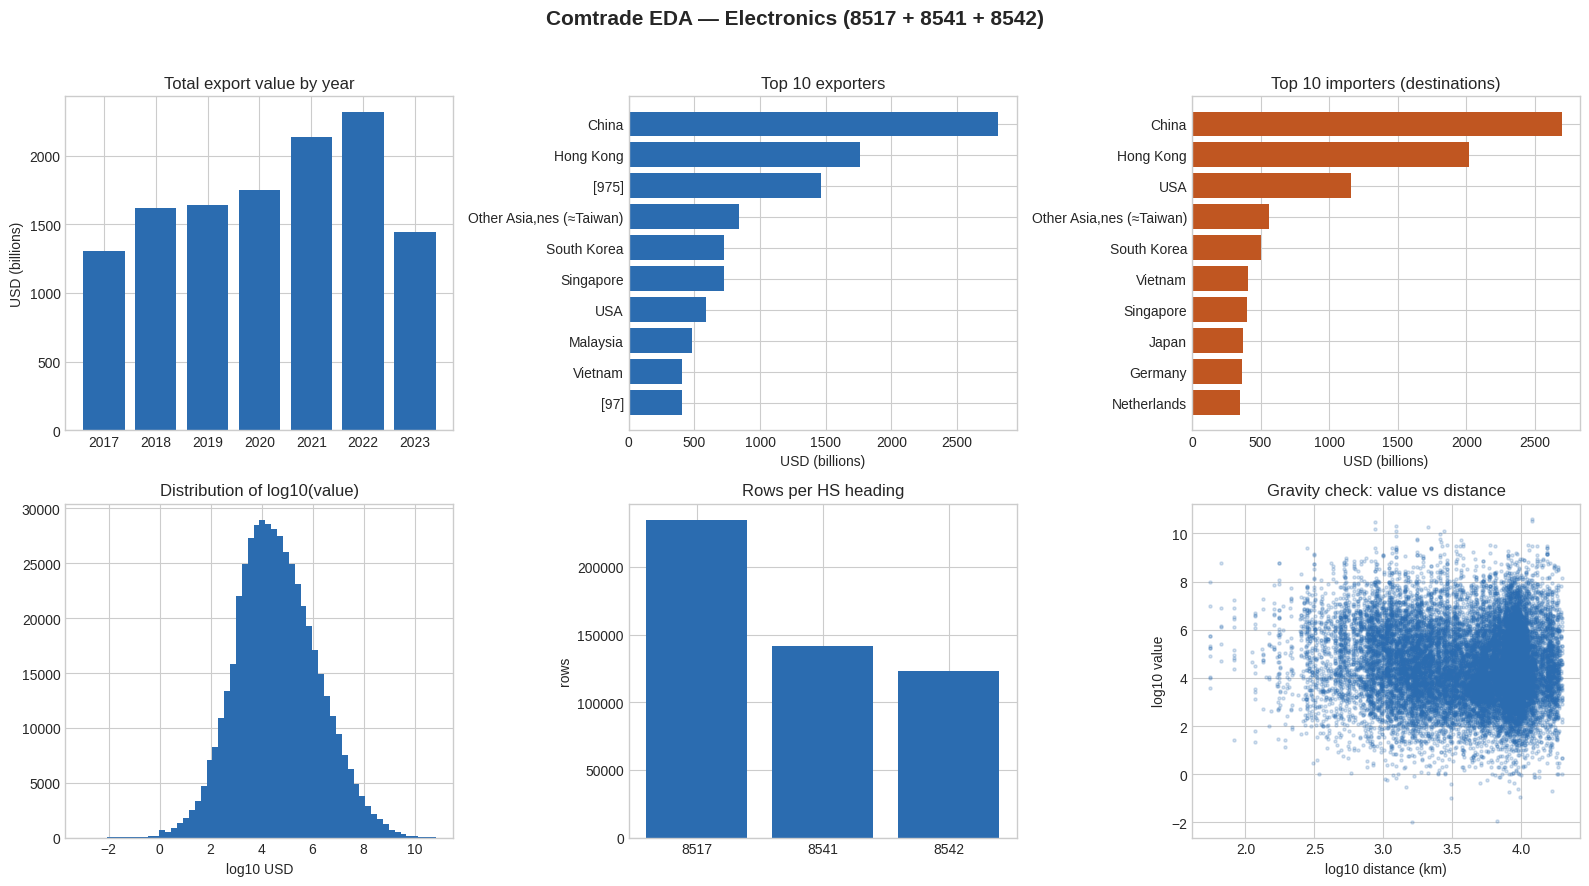

EDA — Coffee (0901 + 2101)
Rows:        64,075
Years:       2017 – 2023
Exporters:   150    Importers: 232
Total value: $73.4B

Top 5 exporters by value:
  [97]                       $8.3B
  Germany                    $6.8B
  [975]                      $4.9B
  Brazil                     $4.4B
  Netherlands                $3.7B


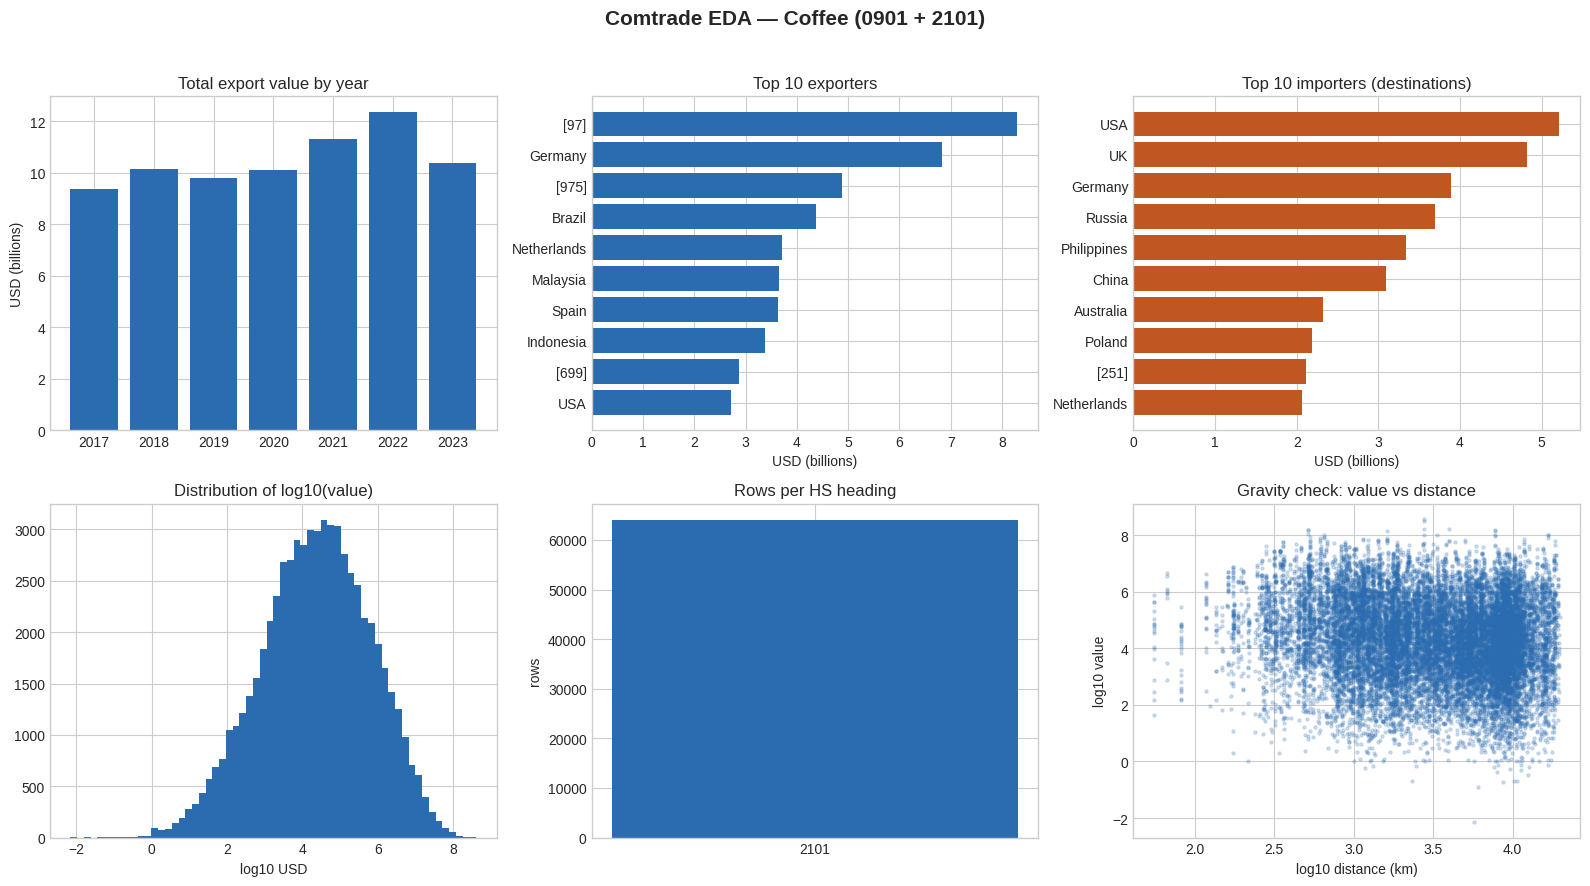

In [10]:
eda(chips, "Chips (8541 + 8542)")
eda(elec,  "Electronics (8517 + 8541 + 8542)")
eda(coffee, "Coffee (0901 + 2101)")

In [11]:
def date_audit(df, value="primaryValue"):
    d = df.copy()
    d["refYear"] = pd.to_numeric(d["refYear"], errors="coerce")
    d[value]     = pd.to_numeric(d[value], errors="coerce")
    g = d.groupby("refYear").agg(
        rows      =("refYear", "size"),
        value_bn  =(value, lambda s: s.sum() / 1e9),
        exporters =("reporterCode", "nunique"),
        importers =("partnerCode", "nunique"),
    )
    print(g.to_string())
    return g

In [12]:
from country_codes import cname, drop_blocs, CODE2ISO3, ISO3_2_M49
print(cname(156), cname(842), cname(975))      # China USA ASEAN
print(CODE2ISO3["410"], ISO3_2_M49["KOR"])     # KOR 410

China USA ASEAN
KOR 410


In [13]:
import pandas as pd
from country_codes import drop_blocs
chips = drop_blocs(pd.read_parquet("chips.parquet"))
date_audit(chips)

drop_blocs: removed 17,892 bloc rows (ASEAN, EU, …)
          rows     value_bn  exporters  importers
refYear                                          
2017     32069   610.277093         99        238
2018     35298   797.184752        121        239
2019     36296   816.179957        132        241
2020     35744   901.738344        133        240
2021     37673  1153.679170        139        238
2022     36724  1244.042268        128        238
2023     33120   816.493735        101        241


,rows,value_bn,exporters,importers
refYear,,,,
2017,32069,610.277093,99,238
2018,35298,797.184752,121,239
2019,36296,816.179957,132,241
2020,35744,901.738344,133,240
2021,37673,1153.679170,139,238
2022,36724,1244.042268,128,238
2023,33120,816.493735,101,241


EDA — Chips (cleaned)
Rows:        246,924
Years:       2017 – 2023
Exporters:   154    Importers: 244
Total value: $6,339.6B

Top 5 exporters by value:
  Hong Kong                  $1,258.2B
  China                      $1,117.5B
  Other Asia,nes (≈Taiwan)   $786.3B
  Singapore                  $645.4B
  South Korea                $611.7B


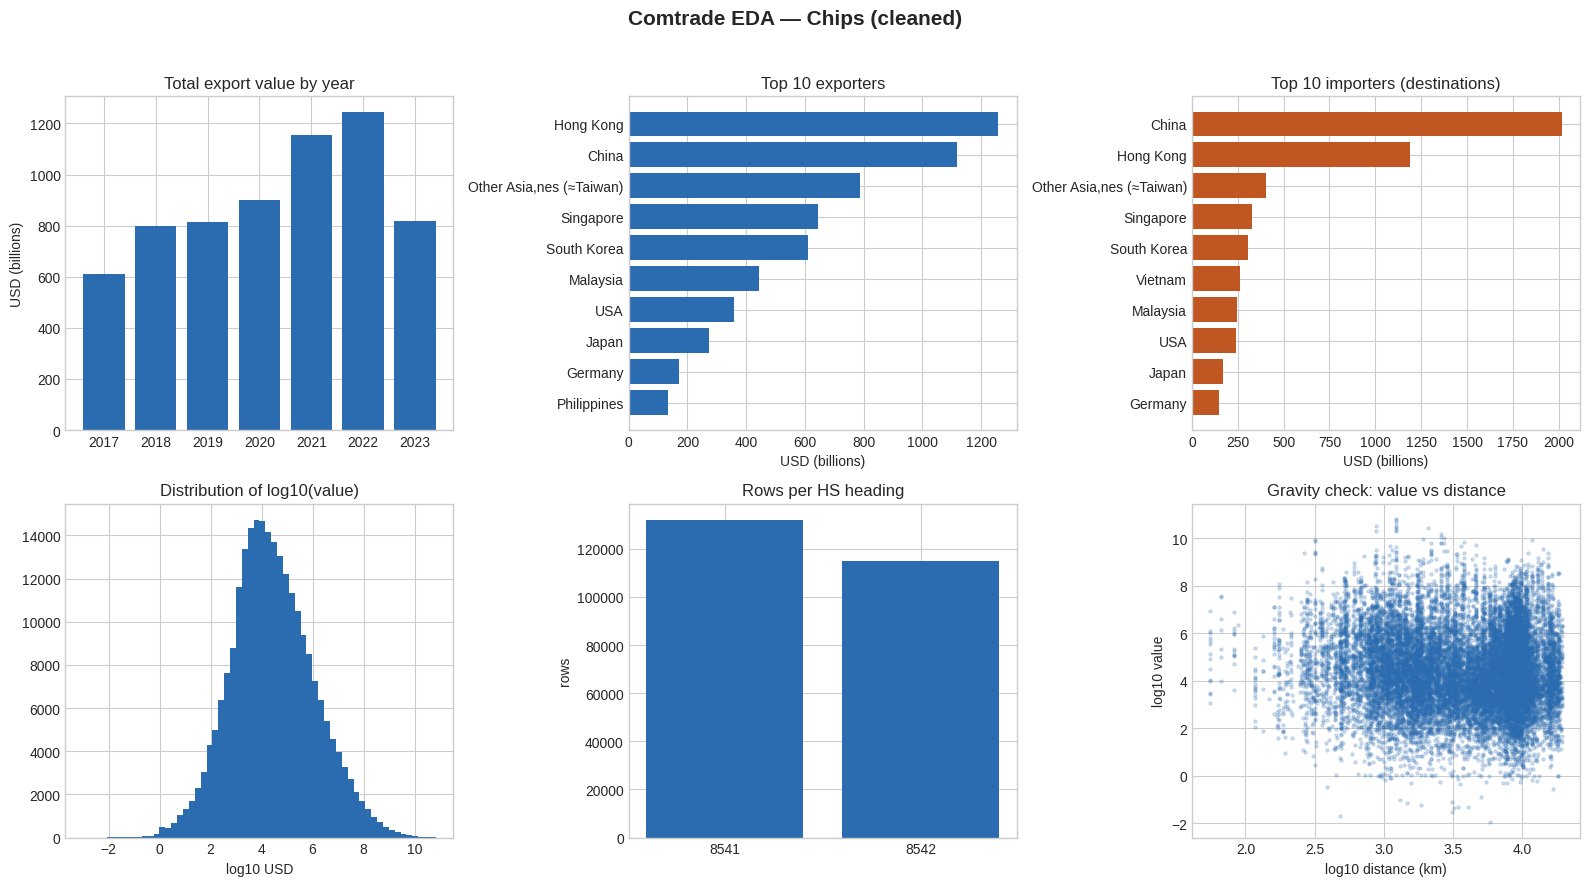

In [14]:
eda(chips, "Chips (cleaned)")